# 01 - Thu thập dữ liệu tử vong Việt Nam

**Mục tiêu:** tải và kiểm tra dữ liệu từ UN WPP (nguồn chính), đối chiếu GSO.

**Checklist:**
- Tải bảng sống tuổi đơn UN WPP (1950–nay) vào `data/raw/`
- Tải bảng sống rút gọn GSO (2009, 2019) vào `data/external/`
- Kiểm tra tính liên tục theo năm, missing values
- Chạy `python -m src.data.make_dataset` để dựng Dxt, Ext
- Ghi chú nguồn + ngày tải vào `data/external/SOURCES.md`

## Tải dữ liệu Bảng sống từ UN WPP

Tải thủ công 3 file "Single age life table estimates" tại https://population.un.org/wpp/ (mục *Life Tables*):

| Giới tính | Tên file (đặt vào `data/raw/`) |
|---|---|
| Cả hai giới | `WPP2024_MORT_F06_1_SINGLE_AGE_LIFE_TABLE_ESTIMATES_BOTH_SEXES.xlsx` |
| Nam | `WPP2024_MORT_F06_2_SINGLE_AGE_LIFE_TABLE_ESTIMATES_MALE.xlsx` |
| Nữ | `WPP2024_MORT_F06_3_SINGLE_AGE_LIFE_TABLE_ESTIMATES_FEMALE.xlsx` |

Ghi lại ngày tải vào `data/external/SOURCES.md`. Bảng sống GSO (đối chiếu, không dùng để fit) số hoá thủ công từ báo cáo TĐT thành CSV với cột tối thiểu `age`, `sex`, `mx` hoặc `qx`, đặt vào `data/external/`.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [ ]:
from src.config import DATA_RAW, DATA_PROCESSED, load_params
from src.data.make_dataset import WPP_FILES
import pandas as pd

cfg = load_params()
list_files = [f for f in WPP_FILES.values() if (DATA_RAW / f).exists()]
if len(list_files) == 3:
    print("Xác nhận đủ 3 file từ WPP2024")
    for f in list_files:
        print(f)
else:
    print("Thiếu file!")

print("Đọc thử file tổng: WPP2024_MORT_F06_1_SINGLE_AGE_LIFE_TABLE_ESTIMATES_BOTH_SEXES.xlsx")
df = pd.read_excel(DATA_RAW / 'WPP2024_MORT_F06_1_SINGLE_AGE_LIFE_TABLE_ESTIMATES_BOTH_SEXES.xlsx', skiprows=16)
df.head()

Xác nhận đủ 3 file từ WPP2024
WPP2024_MORT_F06_1_SINGLE_AGE_LIFE_TABLE_ESTIMATES_BOTH_SEXES.xlsx
WPP2024_MORT_F06_2_SINGLE_AGE_LIFE_TABLE_ESTIMATES_MALE.xlsx
WPP2024_MORT_F06_3_SINGLE_AGE_LIFE_TABLE_ESTIMATES_FEMALE.xlsx
Đọc thử file tổng: WPP2024_MORT_F06_1_SINGLE_AGE_LIFE_TABLE_ESTIMATES_BOTH_SEXES.xlsx


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,United Nations,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,Population Division,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from src.data.make_dataset import main as build_dataset

missing = [f for f in WPP_FILES.values() if not (DATA_RAW / f).exists()]
if missing:
    print("Còn thiếu trong data/raw/:")
    for f in missing:
        print(" -", f)
else:
    print("Đã có đủ 3 file UN WPP, dựng Dxt/Ext...")
    build_dataset()

Đã có đủ 3 file UN WPP, dựng Dxt/Ext...
[ok] male: 101 tuổi x 69 năm -> data/processed/*_male.csv
[ok] female: 101 tuổi x 69 năm -> data/processed/*_female.csv
[ok] total: 101 tuổi x 69 năm -> data/processed/*_total.csv


## Kiểm tra nhanh sau khi dựng ma trận

Dựng ma trận tử vong dựa vào ma trận sống và ma trện chết (không phân biệt giới tính), sau đó kiểm tra nhanh ma trận tử vong này.

In [5]:
import pandas as pd

Dxt = pd.read_csv(DATA_PROCESSED / "Dxt_total.csv", index_col=0)
Dxt.columns = Dxt.columns.astype(int)
Ext = pd.read_csv(DATA_PROCESSED / "Ext_total.csv", index_col=0)
Ext.columns = Ext.columns.astype(int)

print("Dxt:", Dxt.shape, "| tuổi", Dxt.index.min(), "-", Dxt.index.max(),
      "| năm", Dxt.columns.min(), "-", Dxt.columns.max())
print("Số ô thiếu:", Dxt.isna().sum().sum())
mx = Dxt / Ext
print("mx min/max:", mx.values.min(), mx.values.max())
mx.head()

Dxt: (101, 69) | tuổi 0 - 100 | năm 1955 - 2023
Số ô thiếu: 0
mx min/max: 0.0005654464988328192 0.9228147065984903


,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
age,,,,,,,,,,,,,,,,,,,,,
0,0.084267,0.081431,0.078614,0.075878,0.073216,0.070697,0.068507,0.067386,0.067955,0.066451,...,0.016806,0.016656,0.016502,0.016347,0.016204,0.015991,0.015839,0.015651,0.015461,0.015277
1,0.018970,0.017733,0.016574,0.015544,0.014539,0.013650,0.012954,0.013016,0.014092,0.013728,...,0.001733,0.001710,0.001697,0.001686,0.001662,0.001639,0.001629,0.001601,0.001581,0.001563
2,0.015060,0.014147,0.013307,0.012538,0.011800,0.011115,0.010582,0.010536,0.011172,0.010845,...,0.001513,0.001494,0.001483,0.001470,0.001449,0.001429,0.001420,0.001399,0.001382,0.001366
3,0.012010,0.011336,0.010729,0.010155,0.009615,0.009088,0.008692,0.008648,0.009133,0.008881,...,0.001353,0.001339,0.001331,0.001317,0.001297,0.001276,0.001266,0.001246,0.001231,0.001218
4,0.009619,0.009119,0.008679,0.008249,0.007855,0.007449,0.007158,0.007135,0.007544,0.007373,...,0.001229,0.001219,0.001214,0.001200,0.001179,0.001158,0.001148,0.001127,0.001110,0.001098


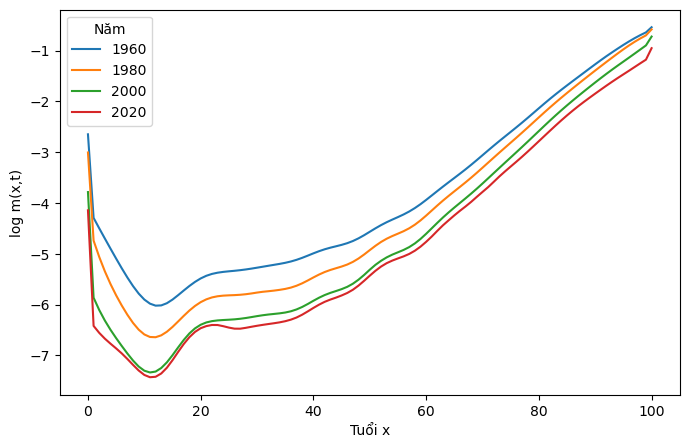

In [6]:
from src.visualization.plots import plot_log_mx_by_age

plot_log_mx_by_age(mx, years=[1960, 1980, 2000, 2020])

## Thu thập dữ liệu Bảng sống từ Báo cáo Tổng điểu tra dân số 2019
Tải báo cáo Tổng điều tra dân số 2019 từ . Xác định Bảng sống theo giới tính được ghi nhận ở `Biểu 6.7`, `trang 96` trong báo cáo. Tuy nhiên, báo cáo được định dạng PDF, để có thể sử dụng, cần lấy dữ liệu theo định dạnh CSV.

| Dữ liệu | Tên file|
|---|---|
| Báo cáo TĐT Dân số 2019 | `TDT-Dan-so-2019-1.pdf` |
| Dữ liệu Bảng sống theo giới tính trích xuất từ TĐT | `gso_bang_song_tdt2019.csv` |